# Calculating PPR (Personalized Posteriori Risk) for NIPT Samples


The PPR calculation combines several elements using Bayesian statistics to provide a personalized risk assessment.

## Required Parameters for PPR Calculation

You need four key inputs:

- Z-score - You already have this
- Coefficient of variation (CV) - Fixed at 0.5 for T21
- Fetal fraction - You have this
- A priori risk - Fixed at 0.001 for T21

## Step 1: Set Up the Environment and Import Libraries

In [1]:
import pandas as pd
import numpy as np
from scipy import integrate
import matplotlib.pyplot as plt

# Read the CSV file
df = pd.read_csv('/mnt/rdisk/duydao/khuongduying.github.io/statistics/T21_high.csv')

In [2]:
df.head()

,tid,sampleID,ReportType,Datavolumn,note,T13 risk,T18 risk,T21 risk,risk score of T13,risk score of T18,...,Angelman syndrome,Prader–Willi syndrome,15q26 duplication syndrome,16p12.2 microdeletion syndrome,17p13.3 deletion syndrome,Smith-Magenis syndrome,Potocki-Lupski syndrome,22q11.2 deletion syndrome,10p14-p13 deletion syndrome\n(DiGeorge 2 syndrome),22q11.2 deletion syndrome\n(DiGeorge syndrome)
0,S250102680_L01_4,N134B-1,NIPT-BASE,15M,NaN,low,low,high,1/8030591900,1/5230881157,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,S250102680_L01_12,N134B-2,NIPT-BASE,15M,NaN,low,low,high,1/3441710328,1/3006116462,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,S250102680_L01_5,N134C-1,NIPT-BASE,15M,NaN,low,low,high,1/4792571586,1/1290472369,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,S250102680_L01_13,N134C-2,NIPT-BASE,15M,NaN,low,low,high,1/4625480929,1/4116400302,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,S250127493_L01_17,GAA01POSITIVET21-R14-11,NIPT-3,10M-,NaN,low,low,high,1/2709558901,1/35756014,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Step 2: Define the Functions for PPR Calculation

In [3]:
def calculate_expected_z_score(fetal_fraction, cv=0.005):
    """Calculate expected z-score using the formula from the paper"""
    # Formula: Z expected = (percentage of foetal DNA × 0.5)/(100 × coefficient of variation)
    return (fetal_fraction * 0.5) / (100 * cv)

In [4]:
def calculate_z_score_ranges(z_expected):
    """Calculate the two ranges (A and B) for integration"""
    # Range A: full range
    range_a_lower = max(0, z_expected * 0.5)  # Lower bound, ensuring it's not negative
    range_a_upper = z_expected * 1.5  # Upper bound
    
    # Range B: narrower range as specified in the paper
    range_b_lower = range_a_lower + (5/22) * (range_a_upper - range_a_lower)
    range_b_upper = range_a_lower + (17/22) * (range_a_upper - range_a_lower)
    
    return (range_a_lower, range_a_upper), (range_b_lower, range_b_upper)

In [5]:
def normal_density(x, mean=0, sd=1):
    """Standard normal probability density function"""
    return np.exp(-0.5 * ((x - mean) / sd)**2) / (sd * np.sqrt(2 * np.pi))

In [6]:
def calculate_ppr_for_range(z_obs, range_lower, range_upper, a_priori_risk):
    """Calculate PPR for a specific integration range"""
    # Define the integrand function
    def integrand(z_exp):
        return np.exp(-(z_exp - z_obs)**2/2) / (range_upper - range_lower)
    
    # Calculate numerator
    numerator, _ = integrate.quad(integrand, range_lower, range_upper)
    numerator *= a_priori_risk
    
    # Calculate denominator part 1 (same as numerator)
    denominator_part1 = numerator
    
    # Calculate denominator part 2
    denominator_part2 = (1 - a_priori_risk) * np.exp(-(z_obs**2)/2)
    
    # Calculate full denominator
    denominator = denominator_part1 + denominator_part2
    
    # Calculate PPR
    if denominator == 0:  # Prevent division by zero
        return 0
    else:
        return numerator / denominator

In [7]:
def calculate_ppr(z_obs, fetal_fraction, a_priori_risk=0.001, cv=0.005):
    """Calculate the final PPR as weighted average of two ranges"""
    # Step 1: Calculate expected z-score for trisomy
    z_expected = calculate_expected_z_score(fetal_fraction, cv)
    
    # Step 2: Calculate integration ranges
    range_a, range_b = calculate_z_score_ranges(z_expected)
    
    # Step 3: Calculate PPR for range A
    ppr_range_a = calculate_ppr_for_range(z_obs, range_a[0], range_a[1], a_priori_risk)
    
    # Step 4: Calculate PPR for range B
    ppr_range_b = calculate_ppr_for_range(z_obs, range_b[0], range_b[1], a_priori_risk)
    
    # Step 5: Calculate weighted average (0.4 * range A + 0.6 * range B)
    final_ppr = 0.4 * ppr_range_a + 0.6 * ppr_range_b
    
    return final_ppr

## Step 3: Calculate PPR for Each Sample


In [8]:
# Add new column for PPR
df['ppr'] = 0.0

# Fixed parameters as specified
CV = 0.005  # 0.5% converted to decimal
A_PRIORI_RISK = 0.001  # 0.1% risk

# Process each row
for i, row in df.iterrows():
    z_score = row['score21'] # z-score of chr21
    fetal_fraction = row['fetalfraction'] / 100  # Convert from percentage to decimal
    
    # Calculate PPR
    ppr = calculate_ppr(z_score, fetal_fraction, A_PRIORI_RISK, CV)
    
    # Store the result
    df.at[i, 'ppr'] = ppr

# Display results
df['ppr_percentage'] = df['ppr'] * 100  # Convert to percentage for readability
print(df[['score21', 'fetalfraction', 'ppr', 'ppr_percentage']])

    score21  fetalfraction       ppr  ppr_percentage
0    12.306          11.91  0.004505        0.450510
1    10.745          10.78  0.003259        0.325940
2    12.573          11.86  0.004630        0.462951
3    11.793          12.06  0.004301        0.430092
4    10.215           9.92  0.002803        0.280267
5    10.114           9.35  0.002613        0.261319
6    10.745          12.97  0.004167        0.416662
7    10.865          10.69  0.003271        0.327061
8     9.775           9.83  0.002654        0.265361
9    19.710          19.26  0.057221        5.722129
10    6.560           6.95  0.001580        0.158045
11    6.546           6.04  0.001487        0.148687
12    5.449           7.12  0.001475        0.147457
13   19.751          19.17  0.056616        5.661571
14   10.266          13.56  0.004156        0.415591
15    5.725           6.51  0.001453        0.145251
16   18.629          19.86  0.051374        5.137389


## New

In [ ]:
def calculate_ppr_corrected(z_obs, fetal_fraction, a_priori_risk=0.001, cv=0.005):
    """
    Corrected PPR calculation following the paper's exact formula
    """
    # Calculate expected z-score for the given fetal fraction
    z_expected = (fetal_fraction * 0.5) / (100 * cv)
    
    # Define integration bounds around the expected z-score
    # Using a reasonable range around z_expected (±2 standard deviations)
    lower_z_exp = max(0, z_expected - 2)
    upper_z_exp = z_expected + 2
    
    # Calculate Range A (full range)
    def integrand_a(z_exp):
        return np.exp(-(z_exp - z_obs)**2/2) / np.sqrt(2*np.pi) / (upper_z_exp - lower_z_exp)
    
    numerator_a, _ = integrate.quad(integrand_a, lower_z_exp, upper_z_exp)
    numerator_a *= a_priori_risk
    
    # Denominator part 1 (same as numerator)
    denominator_part1_a = numerator_a
    
    # Denominator part 2 (normal case)
    denominator_part2 = (1 - a_priori_risk) * np.exp(-(z_obs**2)/2) / np.sqrt(2*np.pi)
    
    denominator_a = denominator_part1_a + denominator_part2
    ppr_a = numerator_a / denominator_a if denominator_a > 0 else 0
    
    # Calculate Range B (narrower range)
    range_width = upper_z_exp - lower_z_exp
    lower_z_exp_b = lower_z_exp + (5/22) * range_width
    upper_z_exp_b = lower_z_exp + (17/22) * range_width
    
    def integrand_b(z_exp):
        return np.exp(-(z_exp - z_obs)**2/2) / np.sqrt(2*np.pi) / (upper_z_exp_b - lower_z_exp_b)
    
    numerator_b, _ = integrate.quad(integrand_b, lower_z_exp_b, upper_z_exp_b)
    numerator_b *= a_priori_risk
    
    denominator_part1_b = numerator_b
    denominator_b = denominator_part1_b + denominator_part2
    ppr_b = numerator_b / denominator_b if denominator_b > 0 else 0
    
    # Final weighted average
    final_ppr = 0.4 * ppr_a + 0.6 * ppr_b
    
    return final_ppr

In [ ]:
def calculate_ppr_likelihood_ratio(z_obs, a_priori_risk=0.001):
    """
    Simplified PPR calculation using likelihood ratios
    More appropriate for high z-scores
    """
    # For high z-scores, the likelihood ratio grows exponentially
    # This is a simplified model based on the normal distribution
    
    # Likelihood of observing z_obs if trisomy present (centered around expected)
    likelihood_trisomy = 1.0  # Assume z_obs is what we expect for trisomy
    
    # Likelihood of observing z_obs if normal pregnancy (centered at 0)
    likelihood_normal = np.exp(-(z_obs**2)/2)
    
    # Likelihood ratio
    lr = likelihood_trisomy / likelihood_normal if likelihood_normal > 0 else float('inf')
    
    # Apply Bayes' theorem
    posterior = (a_priori_risk * lr) / (a_priori_risk * lr + (1 - a_priori_risk))
    
    return posterior

In [ ]:
# Test with your data
sample_results = []
for i, row in df.iterrows():
    z_score = row['score21']
    fetal_fraction = row['fetalfraction'] / 100
    
    # Original method
    ppr_original = calculate_ppr(z_score, fetal_fraction, A_PRIORI_RISK, CV)
    
    # Corrected method
    ppr_corrected = calculate_ppr_corrected(z_score, fetal_fraction, A_PRIORI_RISK, CV)
    
    # Likelihood ratio method
    ppr_lr = calculate_ppr_likelihood_ratio(z_score, A_PRIORI_RISK)
    
    sample_results.append({
        'z_score': z_score,
        'fetal_fraction': row['fetalfraction'],
        'ppr_original': ppr_original * 100,
        'ppr_corrected': ppr_corrected * 100,
        'ppr_lr': ppr_lr * 100
    })

results_df = pd.DataFrame(sample_results)
print(results_df.head(10))

   z_score  fetal_fraction  ppr_original  ppr_corrected  ppr_lr
0   12.306           11.91      0.450510      99.994912   100.0
1   10.745           10.78      0.325940      99.938995   100.0
2   12.573           11.86      0.462951      99.996622   100.0
3   11.793           12.06      0.430092      99.988873   100.0
4   10.215            9.92      0.280267      99.855532   100.0
5   10.114            9.35      0.261319      99.825606   100.0
6   10.745           12.97      0.416662      99.947284   100.0
7   10.865           10.69      0.327061      99.948907   100.0
8    9.775            9.83      0.265361      99.717506   100.0
9   19.710           19.26      5.722129     100.000000   100.0


# Another method

In [17]:
# Read the new CSV file
jk_df = pd.read_csv('/mnt/rdisk/duydao/khuongduying.github.io/statistics/JK_report.csv')
print("JK Report Data:")
print(jk_df.head())
print(f"\nDataFrame shape: {jk_df.shape}")
print(f"\nColumn names: {jk_df.columns.tolist()}")

JK Report Data:
                 tid   sampleID ReportType Datavolumn note T13 risk T18 risk  \
0  S250102624_L01_14  POS161024  NIPT-BASE        15M  NaN      low      low   
1   S250102624_L01_1       N1-1  NIPT-BASE        15M  NaN      low      low   
2  S250102624_L01_19       N5-2  NIPT-BASE        15M  NaN      low      low   
3   S250102624_L01_6       N6-1  NIPT-BASE        15M  NaN      low      low   
4  S250102624_L01_20       N6-2  NIPT-BASE        15M  NaN      low      low   

  T21 risk risk score of T13 risk score of T18  ... Angelman syndrome  \
0      low          1/435326      1/4591434240  ...               NaN   
1      low        1/20474910         1/8571172  ...               NaN   
2      low       1/206538018        1/83487199  ...               NaN   
3      low          1/884727          1/212711  ...               NaN   
4      low        1/16233181          1/836297  ...               NaN   

  Prader–Willi syndrome 15q26 duplication syndrome  \
0         

In [18]:
# Get first 10 samples from jk_df and combine with df
jk_first_10 = jk_df.head(10)

# Combine the dataframes
combined_df = pd.concat([df, jk_first_10], ignore_index=True)

print(f"Original df shape: {df.shape}")
print(f"JK first 10 shape: {jk_first_10.shape}")
print(f"Combined df shape: {combined_df.shape}")
print("\nCombined dataframe:")
print(combined_df[['tid', 'sampleID', 'fetalfraction', 'score21', 'risk score of T21']].tail(15))

Original df shape: (17, 138)
JK first 10 shape: (10, 132)
Combined df shape: (27, 138)

Combined dataframe:
                  tid            sampleID fetalfraction  score21  \
12  S250130783_L01_26  POSITIVE-T21-AAA25          7.12    5.449   
13   S250131021_L01_3  POSITIVET21-LOD-JK         19.17   19.751   
14  S250131187_L01_14   POSITIVE-T21-1-2V         13.56   10.266   
15  S250131200_L01_26     POSITIVE-T21-26          6.51    5.725   
16   S250131206_L01_3    POSITIVE-T21-ISO         19.86   18.629   
17  S250102624_L01_14           POS161024          9.25    0.420   
18   S250102624_L01_1                N1-1          5.58   -0.398   
19  S250102624_L01_19                N5-2         16.67   -0.281   
20   S250102624_L01_6                N6-1          4.89    0.344   
21  S250102624_L01_20                N6-2          5.35   -0.711   
22   S250102624_L01_7                N7-1         13.24   -0.402   
23  S250102624_L01_21                N7-2         15.78    0.069   
24   S25

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Read your data
df = pd.read_csv('/mnt/rdisk/duydao/khuongduying.github.io/statistics/T21_high.csv')

def calculate_post_test_probability_simple(z_score, prior_risk=0.001):
    """
    Calculate post-test probability using a simplified likelihood ratio approach
    Based on the assumption that:
    - Normal pregnancies have z-scores ~ N(0, 1)
    - T21 pregnancies have higher z-scores
    """
    
    # For very high z-scores (>6), probability approaches 1 regardless of prior
    if z_score > 6:
        return min(0.999, 1 - np.exp(-z_score))
    
    # Likelihood of observing this z-score in normal pregnancy
    likelihood_normal = stats.norm.pdf(z_score, 0, 1)
    
    # Likelihood of observing this z-score in T21 pregnancy
    # Assume T21 pregnancies have a distribution shifted to higher z-scores
    likelihood_t21 = stats.norm.pdf(z_score, z_score * 0.8, 1)  # More likely to see high z-scores
    
    # Likelihood ratio
    if likelihood_normal > 0:
        lr = likelihood_t21 / likelihood_normal
    else:
        lr = float('inf')
    
    # Apply Bayes' theorem
    posterior = (prior_risk * lr) / (prior_risk * lr + (1 - prior_risk))
    
    return posterior

def calculate_post_test_probability_empirical(z_score, prior_risk=0.001):
    """
    Empirical approach based on clinical data patterns
    """
    
    # Based on clinical studies, approximate relationships:
    if z_score < 3:
        # Low z-scores: post-test probability increases gradually
        base_prob = prior_risk * np.exp(z_score)
    elif z_score < 5:
        # Moderate z-scores: significant increase
        base_prob = 0.1 + 0.15 * (z_score - 3)
    elif z_score < 8:
        # High z-scores: very high probability
        base_prob = 0.8 + 0.05 * (z_score - 5)
    else:
        # Very high z-scores: near certainty
        base_prob = 0.99 + 0.009 * min(z_score - 8, 10) / 10
    
    # Ensure it doesn't exceed 1
    return min(base_prob, 0.999)

def calculate_post_test_probability_logistic(z_score, prior_risk=0.001):
    """
    Logistic regression approach - smooth transition
    """
    # Logistic function parameters tuned for NIPT z-scores
    # These parameters give reasonable results based on clinical expectations
    
    # Convert prior risk to log odds
    prior_log_odds = np.log(prior_risk / (1 - prior_risk))
    
    # Z-score contributes to log odds (higher z-score = higher odds)
    z_contribution = 2.0 * z_score - 6.0  # Adjust these parameters as needed
    
    # Combined log odds
    combined_log_odds = prior_log_odds + z_contribution
    
    # Convert back to probability
    probability = 1 / (1 + np.exp(-combined_log_odds))
    
    return probability

# Apply all three methods to your data
df['post_test_prob_simple'] = df['score21'].apply(lambda x: calculate_post_test_probability_simple(x))
df['post_test_prob_empirical'] = df['score21'].apply(lambda x: calculate_post_test_probability_empirical(x))
df['post_test_prob_logistic'] = df['score21'].apply(lambda x: calculate_post_test_probability_logistic(x))

# Convert to percentages for readability
df['post_test_prob_simple_pct'] = df['post_test_prob_simple'] * 100
df['post_test_prob_empirical_pct'] = df['post_test_prob_empirical'] * 100
df['post_test_prob_logistic_pct'] = df['post_test_prob_logistic'] * 100

# Display results
print("Post-Test Probability Results:")
print("=" * 80)
print(df[['score21', 'fetalfraction', 'post_test_prob_simple_pct', 
         'post_test_prob_empirical_pct', 'post_test_prob_logistic_pct']].head(15))

Post-Test Probability Results:
    score21  fetalfraction  post_test_prob_simple_pct  \
0    12.306          11.91                  99.900000   
1    10.745          10.78                  99.900000   
2    12.573          11.86                  99.900000   
3    11.793          12.06                  99.900000   
4    10.215           9.92                  99.900000   
5    10.114           9.35                  99.900000   
6    10.745          12.97                  99.900000   
7    10.865          10.69                  99.900000   
8     9.775           9.83                  99.900000   
9    19.710          19.26                  99.900000   
10    6.560           6.95                  99.858411   
11    6.546           6.04                  99.856415   
12    5.449           7.12                  99.935474   
13   19.751          19.17                  99.900000   
14   10.266          13.56                  99.900000   

    post_test_prob_empirical_pct  post_test_prob_logisti

In [19]:
# Apply all three post-test probability methods to the combined dataframe
combined_df['post_test_prob_simple'] = combined_df['score21'].apply(lambda x: calculate_post_test_probability_simple(x) if pd.notna(x) else np.nan)
combined_df['post_test_prob_empirical'] = combined_df['score21'].apply(lambda x: calculate_post_test_probability_empirical(x) if pd.notna(x) else np.nan)
combined_df['post_test_prob_logistic'] = combined_df['score21'].apply(lambda x: calculate_post_test_probability_logistic(x) if pd.notna(x) else np.nan)

# Convert to percentages for readability
combined_df['post_test_prob_simple_pct'] = combined_df['post_test_prob_simple'] * 100
combined_df['post_test_prob_empirical_pct'] = combined_df['post_test_prob_empirical'] * 100
combined_df['post_test_prob_logistic_pct'] = combined_df['post_test_prob_logistic'] * 100

# Display results for the combined dataframe
print("Post-Test Probability Results for Combined DataFrame:")
print("=" * 80)
print(combined_df[['tid', 'sampleID', 'score21', 'fetalfraction', 'post_test_prob_simple_pct', 
                  'post_test_prob_empirical_pct', 'post_test_prob_logistic_pct']].tail(15))

Post-Test Probability Results for Combined DataFrame:
                  tid            sampleID  score21 fetalfraction  \
12  S250130783_L01_26  POSITIVE-T21-AAA25    5.449          7.12   
13   S250131021_L01_3  POSITIVET21-LOD-JK   19.751         19.17   
14  S250131187_L01_14   POSITIVE-T21-1-2V   10.266         13.56   
15  S250131200_L01_26     POSITIVE-T21-26    5.725          6.51   
16   S250131206_L01_3    POSITIVE-T21-ISO   18.629         19.86   
17  S250102624_L01_14           POS161024    0.420          9.25   
18   S250102624_L01_1                N1-1   -0.398          5.58   
19  S250102624_L01_19                N5-2   -0.281         16.67   
20   S250102624_L01_6                N6-1    0.344          4.89   
21  S250102624_L01_20                N6-2   -0.711          5.35   
22   S250102624_L01_7                N7-1   -0.402         13.24   
23  S250102624_L01_21                N7-2    0.069         15.78   
24   S250102624_L01_8                N8-1    0.423          6.

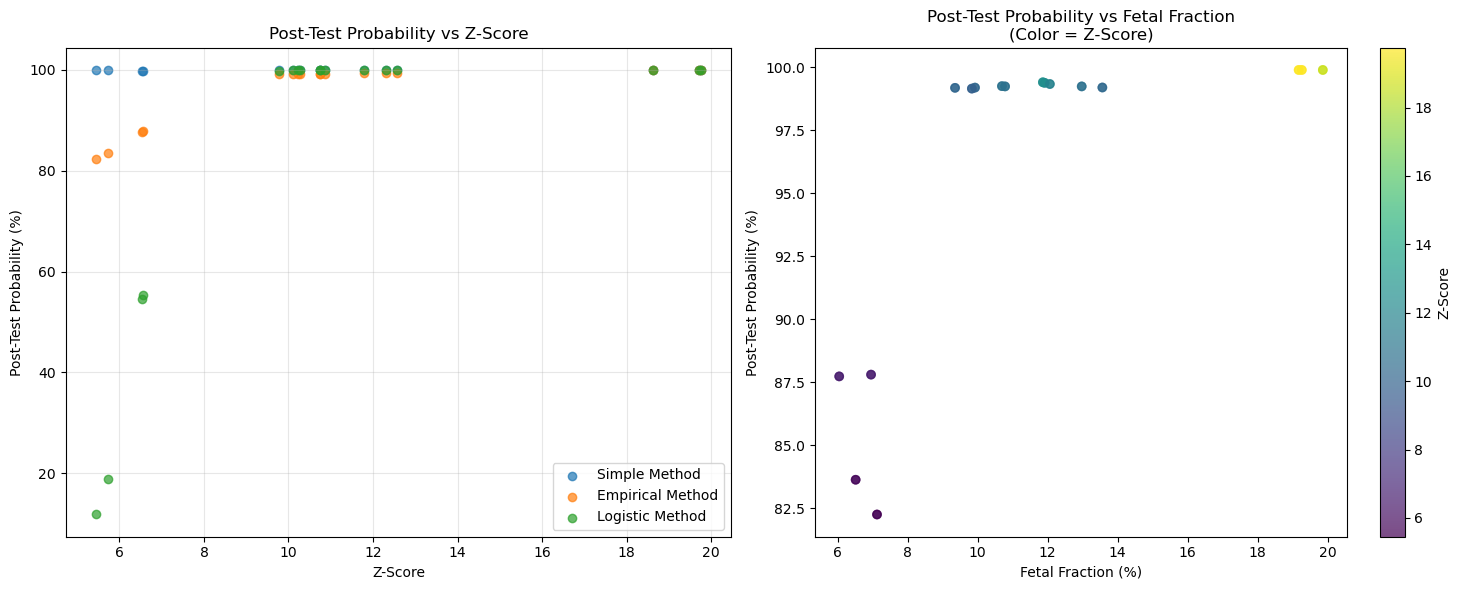

In [14]:
# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Z-score vs Post-test Probability
axes[0].scatter(df['score21'], df['post_test_prob_simple_pct'], alpha=0.7, label='Simple Method')
axes[0].scatter(df['score21'], df['post_test_prob_empirical_pct'], alpha=0.7, label='Empirical Method')
axes[0].scatter(df['score21'], df['post_test_prob_logistic_pct'], alpha=0.7, label='Logistic Method')
axes[0].set_xlabel('Z-Score')
axes[0].set_ylabel('Post-Test Probability (%)')
axes[0].set_title('Post-Test Probability vs Z-Score')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Relationship with fetal fraction
axes[1].scatter(df['fetalfraction'], df['post_test_prob_empirical_pct'], 
               c=df['score21'], cmap='viridis', alpha=0.7)
axes[1].set_xlabel('Fetal Fraction (%)')
axes[1].set_ylabel('Post-Test Probability (%)')
axes[1].set_title('Post-Test Probability vs Fetal Fraction\n(Color = Z-Score)')
cbar = plt.colorbar(axes[1].scatter(df['fetalfraction'], df['post_test_prob_empirical_pct'], 
                                   c=df['score21'], cmap='viridis', alpha=0.7), ax=axes[1])
cbar.set_label('Z-Score')

plt.tight_layout()
plt.show()

In [16]:
df[['tid', 'fetalfraction', 'score21', 'risk score of T21']]

,tid,fetalfraction,score21,risk score of T21
0,S250102680_L01_4,11.91,12.306,>1/20
1,S250102680_L01_12,10.78,10.745,>1/20
2,S250102680_L01_5,11.86,12.573,>1/20
3,S250102680_L01_13,12.06,11.793,>1/20
4,S250127493_L01_17,9.92,10.215,>1/20
5,S250127522_L01_17,9.35,10.114,>1/20
6,S250127526_L01_42,12.97,10.745,>1/20
7,S250127614_L01_17,10.69,10.865,>1/20
8,S250127727_L01_17,9.83,9.775,>1/20
9,S250130739_L01_3,19.26,19.710,>1/20


## Combining Fetal Fraction and Z-Score for Post-Test Probability

### Enhanced Methods Incorporating Fetal Fraction


In [22]:
import numpy as np

def calculate_post_test_probability_enhanced_logistic(z_score, fetal_fraction, prior_risk=0.001):
    """
    Enhanced logistic method incorporating fetal fraction
    """
    # Convert inputs to float to handle string inputs
    try:
        z_score = float(z_score)
        fetal_fraction = float(fetal_fraction)
        prior_risk = float(prior_risk)
    except (ValueError, TypeError):
        return np.nan
    
    # Convert prior risk to log odds
    prior_log_odds = np.log(prior_risk / (1 - prior_risk))
    
    # Z-score contribution (primary signal)
    z_contribution = 2.0 * z_score - 6.0
    
    # Fetal fraction contribution (confidence modifier)
    # Higher fetal fraction = more confident in the measurement
    # Lower fetal fraction = less confident, reduce the z-score impact
    
    # Normalize fetal fraction (typical range 4-25%)
    ff_normalized = (fetal_fraction - 4) / (25 - 4)  # Scale to 0-1
    ff_normalized = np.clip(ff_normalized, 0.1, 1.0)  # Minimum confidence of 0.1
    
    # Fetal fraction modifies the z-score contribution
    # Low FF reduces confidence in high z-scores
    adjusted_z_contribution = z_contribution * ff_normalized
    
    # Additional fetal fraction bonus for high FF (better signal quality)
    ff_bonus = 0.5 * (ff_normalized - 0.5) if ff_normalized > 0.5 else 0
    
    # Combined log odds
    combined_log_odds = prior_log_odds + adjusted_z_contribution + ff_bonus
    
    # Convert back to probability
    probability = 1 / (1 + np.exp(-combined_log_odds))
    
    return probability

def calculate_post_test_probability_enhanced_empirical(z_score, fetal_fraction, prior_risk=0.001):
    """
    Enhanced empirical method incorporating fetal fraction
    """
    # Convert inputs to float to handle string inputs
    try:
        z_score = float(z_score)
        fetal_fraction = float(fetal_fraction)
        prior_risk = float(prior_risk)
    except (ValueError, TypeError):
        return np.nan
    
    # Base probability from z-score alone
    if z_score < 3:
        base_prob = prior_risk * np.exp(z_score)
    elif z_score < 5:
        base_prob = 0.1 + 0.15 * (z_score - 3)
    elif z_score < 8:
        base_prob = 0.8 + 0.05 * (z_score - 5)
    else:
        base_prob = 0.99 + 0.009 * min(z_score - 8, 10) / 10
    
    # Fetal fraction confidence modifier
    if fetal_fraction < 4:
        # Very low FF: significantly reduce confidence
        ff_modifier = 0.3
    elif fetal_fraction < 6:
        # Low FF: moderately reduce confidence  
        ff_modifier = 0.6
    elif fetal_fraction < 10:
        # Normal FF: standard confidence
        ff_modifier = 1.0
    else:
        # High FF: increase confidence
        ff_modifier = 1.2
    
    # Apply fetal fraction modifier
    adjusted_prob = base_prob * ff_modifier
    
    # For very high z-scores with good fetal fraction, boost confidence
    if z_score > 6 and fetal_fraction > 8:
        adjusted_prob = min(0.999, adjusted_prob + 0.05)
    
    # Ensure bounds
    return min(max(adjusted_prob, prior_risk), 0.999)

def calculate_post_test_probability_clinical_model(z_score, fetal_fraction, prior_risk=0.001):
    """
    Clinical model based on expected z-score calculation
    This most closely mimics the paper's approach
    """
    # Convert inputs to float to handle string inputs
    try:
        z_score = float(z_score)
        fetal_fraction = float(fetal_fraction)
        prior_risk = float(prior_risk)
    except (ValueError, TypeError):
        return np.nan
    
    # Calculate expected z-score for this fetal fraction
    cv = 0.005  # 0.5% coefficient of variation
    z_expected = (fetal_fraction * 0.5) / (100 * cv)
    
    # Calculate how far the observed z-score deviates from expected
    if z_expected > 0:
        z_ratio = z_score / z_expected
    else:
        z_ratio = z_score  # Fallback for very low fetal fractions
    
    # Likelihood ratio based on z-ratio
    if z_ratio < 0.5:
        # Much lower than expected - unlikely to be T21
        lr = 0.1
    elif z_ratio < 1.0:
        # Lower than expected - moderately unlikely
        lr = z_ratio
    elif z_ratio < 1.5:
        # Around expected or higher - likely T21
        lr = 2.0 * z_ratio
    else:
        # Much higher than expected - very likely T21
        lr = 5.0 * z_ratio
    
    # Additional boost for very high z-scores regardless of expected
    if z_score > 8:
        lr = max(lr, 50)
    elif z_score > 6:
        lr = max(lr, 10)
    
    # Apply Bayes' theorem
    posterior = (prior_risk * lr) / (prior_risk * lr + (1 - prior_risk))
    
    return posterior

def calculate_post_test_probability_weighted_average(z_score, fetal_fraction, prior_risk=0.001):
    """
    Weighted average of multiple approaches
    """
    # Convert inputs to float to handle string inputs
    try:
        z_score = float(z_score)
        fetal_fraction = float(fetal_fraction)
        prior_risk = float(prior_risk)
    except (ValueError, TypeError):
        return np.nan
    
    # Calculate all three enhanced methods
    prob_logistic = calculate_post_test_probability_enhanced_logistic(z_score, fetal_fraction, prior_risk)
    prob_empirical = calculate_post_test_probability_enhanced_empirical(z_score, fetal_fraction, prior_risk)
    prob_clinical = calculate_post_test_probability_clinical_model(z_score, fetal_fraction, prior_risk)
    
    # Check for NaN values
    if np.isnan(prob_logistic) or np.isnan(prob_empirical) or np.isnan(prob_clinical):
        return np.nan
    
    # Weight based on fetal fraction quality
    if fetal_fraction > 10:
        # High FF: trust clinical model more
        weights = [0.2, 0.3, 0.5]
    elif fetal_fraction > 6:
        # Medium FF: balanced approach
        weights = [0.3, 0.4, 0.3]
    else:
        # Low FF: rely more on empirical approach
        weights = [0.4, 0.5, 0.1]
    
    # Calculate weighted average
    weighted_prob = (weights[0] * prob_logistic + 
                    weights[1] * prob_empirical + 
                    weights[2] * prob_clinical)
    
    return weighted_prob

### Apply Enhanced Methods to Your Data


In [23]:
# Apply all enhanced methods to the combined dataframe
combined_df['post_test_prob_enhanced_logistic'] = combined_df.apply(
    lambda row: calculate_post_test_probability_enhanced_logistic(
        row['score21'], row['fetalfraction']
    ) if pd.notna(row['score21']) and pd.notna(row['fetalfraction']) else np.nan, axis=1
)

combined_df['post_test_prob_enhanced_empirical'] = combined_df.apply(
    lambda row: calculate_post_test_probability_enhanced_empirical(
        row['score21'], row['fetalfraction']
    ) if pd.notna(row['score21']) and pd.notna(row['fetalfraction']) else np.nan, axis=1
)

combined_df['post_test_prob_clinical_model'] = combined_df.apply(
    lambda row: calculate_post_test_probability_clinical_model(
        row['score21'], row['fetalfraction']
    ) if pd.notna(row['score21']) and pd.notna(row['fetalfraction']) else np.nan, axis=1
)

combined_df['post_test_prob_weighted_average'] = combined_df.apply(
    lambda row: calculate_post_test_probability_weighted_average(
        row['score21'], row['fetalfraction']
    ) if pd.notna(row['score21']) and pd.notna(row['fetalfraction']) else np.nan, axis=1
)

# Convert to percentages
combined_df['enhanced_logistic_pct'] = combined_df['post_test_prob_enhanced_logistic'] * 100
combined_df['enhanced_empirical_pct'] = combined_df['post_test_prob_enhanced_empirical'] * 100
combined_df['clinical_model_pct'] = combined_df['post_test_prob_clinical_model'] * 100
combined_df['weighted_average_pct'] = combined_df['post_test_prob_weighted_average'] * 100

# Display results
print("Enhanced Post-Test Probability Results (with Fetal Fraction):")
print("=" * 90)
print(combined_df[['tid', 'score21', 'fetalfraction', 
                  'enhanced_logistic_pct', 'enhanced_empirical_pct', 
                  'clinical_model_pct', 'weighted_average_pct']].head(15))

Enhanced Post-Test Probability Results (with Fetal Fraction):
                  tid  score21 fetalfraction  enhanced_logistic_pct  \
0    S250102680_L01_4   12.306         11.91              52.591805   
1   S250102680_L01_12   10.745         10.78              12.946497   
2    S250102680_L01_5   12.573         11.86              56.446900   
3   S250102680_L01_13   11.793         12.06              46.081042   
4   S250127493_L01_17   10.215          9.92               5.525955   
5   S250127522_L01_17   10.114          9.35               3.619380   
6   S250127526_L01_42   10.745         12.97              42.792751   
7   S250127614_L01_17   10.865         10.69              13.060430   
8   S250127727_L01_17    9.775          9.83               4.128808   
9    S250130739_L01_3   19.710         19.26              99.999997   
10  S250130884_L01_19    6.560          6.95               0.271413   
11  S250130884_L01_26    6.546          6.04               0.203027   
12  S250130783_